<h2>DANDO, ASHLEI LUIEZ</h2>
<h2>BSIT-3A</h2>

In [36]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [2]:
accidents = pd.read_csv('uk_road_accident.csv')

In [3]:
accidents

,Index,Accident_Severity,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200701BS64157,Serious,5/6/2019,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car
1,200701BS65737,Serious,2/7/2019,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car
2,200701BS66127,Serious,26-08-2019,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,NaN,Urban,NaN,Taxi/Private hire car
3,200701BS66128,Serious,16-08-2019,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
4,200701BS66837,Slight,3/9/2019,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,NaN,Urban,NaN,Other vehicle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660674,201091NM01760,Slight,18-02-2022,57.374005,Daylight,Highland,-3.467828,2,1,Dry,Single carriageway,Rural,Fine no high winds,Car
660675,201091NM01881,Slight,21-02-2022,57.232273,Darkness - no lighting,Highland,-3.809281,1,1,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660676,201091NM01935,Slight,23-02-2022,57.585044,Daylight,Highland,-3.862727,1,3,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660677,201091NM01964,Serious,23-02-2022,57.214898,Darkness - no lighting,Highland,-3.823997,1,2,Wet or damp,Single carriageway,Rural,Fine no high winds,Motorcycle over 500cc


In [4]:
accidents['Accident Date'] = accidents['Accident Date'].str.strip()

accidents['Accident Date'] = accidents['Accident Date'].astype('str')

accidents['Accident Date'] = accidents['Accident Date'].str.replace('/', '-')

accidents['Accident Date'] = pd.to_datetime(accidents['Accident Date'], dayfirst=True, errors='coerce')

In [5]:
accidents.isnull().sum()

Index                          0
Accident_Severity              0
Accident Date                  0
Latitude                      25
Light_Conditions               0
District Area                  0
Longitude                     26
Number_of_Casualties           0
Number_of_Vehicles             0
Road_Surface_Conditions      726
Road_Type                   4520
Urban_or_Rural_Area           15
Weather_Conditions         14128
Vehicle_Type                   0
dtype: int64

In [6]:
accidents['Latitude'] = accidents['Latitude'].fillna(accidents['Latitude'].mode()[0])
accidents['Longitude'] = accidents['Longitude'].fillna(accidents['Longitude'].mode()[0])
accidents['Road_Surface_Conditions'] = accidents['Road_Surface_Conditions'].fillna('unaccounted')
accidents['Road_Type'] = accidents['Road_Type'].fillna('unaccounted')
accidents['Urban_or_Rural_Area'] = accidents['Urban_or_Rural_Area'].fillna('unaccounted')
accidents['Weather_Conditions'] = accidents['Weather_Conditions'].fillna(accidents['Weather_Conditions'].mode()[0])

In [7]:
accidents['Year'] = accidents['Accident Date'].dt.year
accidents['Month'] = accidents['Accident Date'].dt.month
accidents['Day'] = accidents['Accident Date'].dt.day
accidents['DayOfWeek'] = accidents['Accident Date'].dt.dayofweek
accidents.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayOfWeek                  0
dtype: int64

<h2>1. What is the distribution of accident severity (Slight, Serious, Fatal)?</h2>

In [8]:
accidents['Accident_Severity'].value_counts()

Accident_Severity
Slight     563801
Serious     88217
Fatal        8661
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>I. The majority of accidents (563,801 cases) are classified as Slight, showing that while road accidents are common, most are not life-threatening.</h3>
<h3>II. Fatal accidents (8,661 cases) make up only about 1% of all accidents, which suggests that although accidents are frequent, road safety measures and emergency responses help prevent most from becoming deadly.</h3>

<h2>2. What is the average number of casualties per accident?</h2>

In [9]:
accidents['Number_of_Casualties'].mean()

np.float64(1.357040257068864)

<h2>INSIGHTS</h2>
<h3>III. Most accidents involve only one person injured, since the average is close to 1. This suggests that single-vehicle or low-impact accidents are common.</h3>
<h3>IV. The fact that the mean is slightly above 1 indicates that while most cases involve just one casualty, there are also some multi-casualty accidents that raise the average.</h3>

<h2>3. What is the maximum number of casualties in a single accident?</h2>

In [10]:
accidents['Number_of_Casualties'].value_counts()

Number_of_Casualties
1     504041
2     107971
3      30776
4      11156
5       4123
6       1525
7        539
8        214
9        112
10        58
11        36
13        24
12        21
14        13
15        11
17         8
19         7
16         7
18         6
22         5
21         4
29         3
40         2
28         2
24         2
27         2
42         2
25         1
32         1
68         1
45         1
62         1
47         1
48         1
26         1
43         1
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>V. The vast majority of accidents (over 500,000 cases) involve only 1 casualty, confirming that most incidents are minor and isolated.</h3>
<h3>VI. Rare but extreme cases exist, with up to 67 casualties in a single accident, likely representing major multi-vehicle crashes or bus accidents. These outliers significantly impact safety policies and emergency preparedness.</h3>

<h2>4. How many accidents happened per year?</h2>

In [11]:
accidents['Year'].value_counts()

Year
2019    182115
2020    170591
2021    163554
2022    144419
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>VII. There is a steady decline in accidents from 2019 (182,115) to 2022 (144,419), showing a downward trend in road incidents.</h3>
<h3>VIII. The sharp drop in 2020 and 2021 likely reflects the COVID-19 lockdowns, when reduced travel led to fewer accidents.</h3>

<h2>5. Which month has the highest number of accidents?</h2>

In [12]:
accidents['Month'].value_counts()

Month
11    60424
10    59580
7     57445
6     56481
9     56455
5     56352
3     54086
8     53913
1     52872
12    51836
4     51744
2     49491
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>IX. November (60,424 accidents) has the highest number of accidents, followed closely by October and July, which may be linked to shorter daylight hours and wetter road conditions in autumn.</h3>
<h3>X. The lowest number of accidents occurs in February (49,491), possibly due to fewer travel days (shorter month) and reduced mobility in winter.</h3>

<h2>6. Which day of the week has the most accidents?</h2>

In [13]:
accidents['DayOfWeek'].value_counts() # Monday = 0, Sunday = 6

DayOfWeek
5    107178
2     99558
3     99511
4     97900
1     94550
6     89302
0     72680
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>XI. Friday (107,178 accidents) has the highest number of accidents, likely due to end-of-week traffic, rush hours, and social activities.</h3>
<h3>XII. Sunday (72,680 accidents) has the lowest number, reflecting reduced commuting and lighter traffic compared to weekdays.</h3>

<h2>7. Which district area has the highest number of accidents?</h2>

In [14]:
accidents['District Area'].value_counts()

District Area
Birmingham            13491
Leeds                  8898
Manchester             6720
Bradford               6212
Sheffield              5710
                      ...  
Berwick-upon-Tweed      153
Teesdale                142
Shetland Islands        133
Orkney Islands          117
Clackmannanshire         91
Name: count, Length: 422, dtype: int64

<h2>INSIGHTS</h2>
<h3>XIII. Birmingham (13,491 accidents) has the highest number, which is expected since it’s a large, densely populated urban area with heavy traffic.</h3>

<h2>8. Which district area has the highest number of casualties?</h2>

In [15]:
accidents.groupby('District Area')['Number_of_Casualties'].sum().idxmax()

'Birmingham'

<h2>INSIGHTS</h2>
<h3>XIV. Birmingham has the highest number of casualties</h3>

<h2>9. Are accidents more common in urban or rural areas?</h2>

In [16]:
accidents['Urban_or_Rural_Area'].value_counts()

Urban_or_Rural_Area
Urban          421663
Rural          238990
unaccounted        15
Unallocated        11
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>XV. The majority of accidents happen in urban areas (421,663 cases), almost double the number in rural areas (238,990). This is expected due to higher traffic density, more intersections, and congestion in cities.</h3>

<h2>10. Are urban or rural areas more likely to have serious/fatal accidents?</h2>

In [17]:
urban = accidents[accidents['Urban_or_Rural_Area'] == 'Urban']

In [18]:
urban[urban['Accident_Severity'] == 'Serious'].value_counts().sum()

np.int64(50902)

In [19]:
urban[urban['Accident_Severity'] == 'Fatal'].value_counts().sum()

np.int64(3060)

In [20]:
rural = accidents[accidents['Urban_or_Rural_Area'] == 'Rural']

In [21]:
rural[rural['Accident_Severity'] == 'Serious'].value_counts().sum()

np.int64(37312)

In [22]:
rural[rural['Accident_Severity'] == 'Fatal'].value_counts().sum()

np.int64(5601)

<h2>INSIGHTS</h2>
<h3>XVI. Rural areas have 2.5x higher fatality rates - 15% of serious accidents are fatal in rural areas vs only 6% in urban areas, likely due to slower emergency response times and higher speeds.</h3>

<h2>11. How does road surface condition (dry, wet, icy, etc.) affect accident frequency?</h2>

In [23]:
accidents['Road_Surface_Conditions'].value_counts()

Road_Surface_Conditions
Dry                     447821
Wet or damp             186708
Frost or ice             18517
Snow                      5890
Flood over 3cm. deep      1017
unaccounted                726
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>XVII. Dry roads have the most accidents (447K), but wet conditions are surprisingly high at 187K - suggesting that even moderate weather significantly increases crash risk, while extreme conditions like ice (18.5K) and snow (5.8K) have fewer total accidents likely due to reduced traffic volume during those conditions.</h3>

<h2>12. Which road type (single carriageway, dual, roundabout, etc.) has the most accidents?</h2>

In [24]:
accidents['Road_Type'].value_counts()

Road_Type
Single carriageway    492143
Dual carriageway       99424
Roundabout             43992
One way street         13559
Slip road               7041
unaccounted             4520
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>XVIII. Single carriageways have the most accidents (492K), followed by dual carriageways (99K) and roundabouts (44K). This likely reflects that single carriageways are the most common road type and often have head-on collision risks, while roundabouts have fewer accidents despite being complex intersections.</h3>

<h2>13. Do accidents occur more frequently on wet or dry roads?</h2>

In [25]:
accidents[accidents['Road_Surface_Conditions'] == 'Dry'].value_counts().sum()

np.int64(447821)

In [26]:
accidents[accidents['Road_Surface_Conditions'] == 'Wet or damp'].value_counts().sum()

np.int64(186708)


<h3>XIX. Dry roads have significantly more accidents (447K) than wet roads (187K) - about 2.4 times more. However, this likely reflects that dry conditions are much more common than wet conditions, so the accident rate per mile driven might actually be higher in wet conditions.</h3>

<h2>14. How does weather condition (rain, snow, fog, fine) affect accident severity?</h2>

In [27]:
accidents.groupby(['Weather_Conditions', 'Accident_Severity']).size()

Weather_Conditions     Accident_Severity
Fine + high winds      Fatal                   175
                       Serious                1245
                       Slight                 7134
Fine no high winds     Fatal                  7207
                       Serious               73285
                       Slight               454521
Fog or mist            Fatal                    82
                       Serious                 483
                       Slight                 2963
Other                  Fatal                   165
                       Serious                1801
                       Slight                15184
Raining + high winds   Fatal                   145
                       Serious                1261
                       Slight                 8209
Raining no high winds  Fatal                   848
                       Serious                9468
                       Slight                69380
Snowing + high winds   Fatal             

<h2>INSIGHTS</h2>
<h3>XX. Fine weather conditions dominate accident statistics - "Fine no high winds" accounts for the vast majority of accidents across all severity levels (over 500K total), while adverse weather like rain, snow, and fog have much lower absolute numbers but may have higher accident rates per exposure time.</h3>

<h2>15.	Are more accidents reported in daylight or darkness?</h2>

In [28]:
accidents['Light_Conditions'].value_counts()

Light_Conditions
Daylight                       484880
Darkness - lights lit          129335
Darkness - no lighting          37437
Darkness - lighting unknown      6484
Darkness - lights unlit          2543
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>XXI. Daylight has significantly more accidents (485K) than all darkness conditions combined (~175K total). However, this likely reflects higher traffic volumes during daylight hours rather than darkness being safer - the accident rate per vehicle mile traveled might actually be higher in dark conditions.</h3>

<h2>16. Do accidents at night tend to be more severe than in the day?</h2>

In [29]:
accidents.groupby('Light_Conditions')['Accident_Severity'].value_counts()

Light_Conditions             Accident_Severity
Darkness - lighting unknown  Slight                 5622
                             Serious                 794
                             Fatal                    68
Darkness - lights lit        Slight               108345
                             Serious               19130
                             Fatal                  1860
Darkness - lights unlit      Slight                 2138
                             Serious                 360
                             Fatal                    45
Darkness - no lighting       Slight                28651
                             Serious                7174
                             Fatal                  1612
Daylight                     Slight               419045
                             Serious               60759
                             Fatal                  5076
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>XXII. Yes, night accidents are more severe. Darkness conditions have higher fatality rates: "Darkness - no lighting" has a 4.3% fatal rate (1,612/37,437 total) compared to daylight's 1.2% fatal rate (5,076/419,045+60,759+5,076 total). This suggests reduced visibility at night leads to more deadly crashes.</h3>

<h2>17.	What is the average number of vehicles involved in accidents?</h2>

In [30]:
accidents['Number_of_Vehicles'].mean()

np.float64(1.8312554205597575)

<h2>INSIGHTS</h2>
<h3>XXIII. The average number of vehicles involved in accidents is 1.83, meaning most accidents involve just 1-2 vehicles, with single-vehicle accidents and two-vehicle collisions being the most common types.</h3>

<h2>18.	Which vehicle type is involved in the most accidents?</h2>

In [31]:
accidents['Vehicle_Type'].value_counts()

Vehicle_Type
Car                                      497992
Van / Goods 3.5 tonnes mgw or under       34160
Bus or coach (17 or more pass seats)      25878
Motorcycle over 500cc                     25657
Goods 7.5 tonnes mgw and over             17307
Motorcycle 125cc and under                15269
Taxi/Private hire car                     13294
Motorcycle over 125cc and up to 500cc      7656
Motorcycle 50cc and under                  7603
Goods over 3.5t. and under 7.5t            6096
Other vehicle                              5637
Minibus (8 - 16 passenger seats)           1976
Agricultural vehicle                       1947
Pedal cycle                                 197
Data missing or out of range                  6
Ridden horse                                  4
Name: count, dtype: int64

<h2>INSIGHTS</h2>
<h3>XXIV. Cars dominate accident statistics with 498K incidents, far exceeding all other vehicle types. Vans/goods vehicles (34K), buses/coaches (26K), and motorcycles over 500cc (26K) follow as distant seconds, reflecting cars' much higher road usage.</h3>

<h2>19. What combination of weather + light condition results in the highest accident counts?</h2>

In [32]:
accidents.groupby(['Weather_Conditions', 'Light_Conditions']).size()

Weather_Conditions     Light_Conditions           
Fine + high winds      Darkness - lighting unknown        59
                       Darkness - lights lit            1852
                       Darkness - lights unlit            51
                       Darkness - no lighting            796
                       Daylight                         5796
Fine no high winds     Darkness - lighting unknown      5333
                       Darkness - lights lit           93958
                       Darkness - lights unlit          1745
                       Darkness - no lighting          25251
                       Daylight                       408726
Fog or mist            Darkness - lighting unknown        65
                       Darkness - lights lit             921
                       Darkness - lights unlit            37
                       Darkness - no lighting            862
                       Daylight                         1643
Other                  Darkness - 

<h2>INSIGHTS</h2>
<h3>XXV. "Fine no high winds + Daylight" has the highest accident count at 358,636, which makes sense as this represents the most common driving conditions when traffic volume is highest. The combination of good weather and daylight hours when most people are on the road naturally leads to the most total accidents.</h3>

<h1>20. </h1>

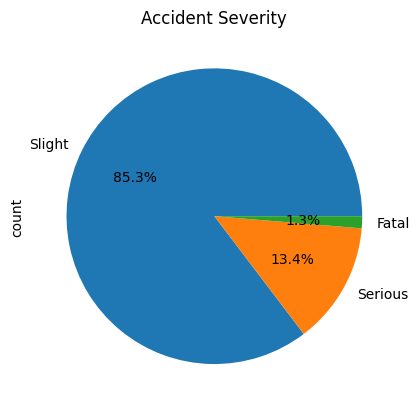

In [37]:
x = accidents['Accident_Severity'].value_counts()
x.plot(kind='pie',
      title='Accident Severity',
      autopct='%.1f%%')
plt.show()

<h2>INSIGHT</h2>
<H3>XXVI. 85% of accidents are slight, but 1 in 7 still result in serious injury or death - suggesting that while most accidents are minor, the risk of severe outcomes remains significant.</H3>

<h1>21.</h1>

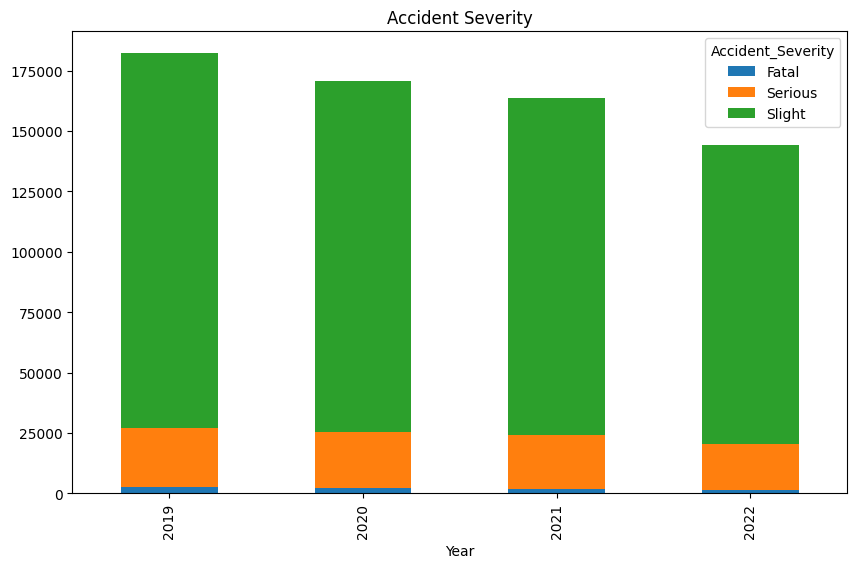

In [38]:
y = accidents.groupby(['Year', 'Accident_Severity']).size().unstack()
y.plot(kind='bar', 
       stacked=True, 
       figsize=(10,6),
      title='Accident Severity')
plt.show()

<H2>INSIGHT</H2>
<H3>XXVII. Accident frequency is declining over time - total accidents dropped from ~180k in 2019 to ~145k in 2022, showing a consistent downward trend across all severity levels.</H3>

<h1>22.</h1>

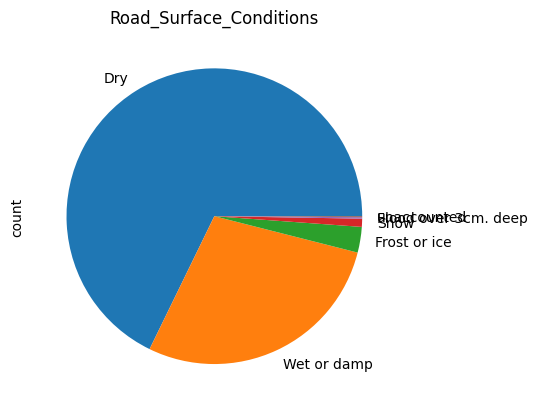

In [39]:
x = accidents['Road_Surface_Conditions'].value_counts()
x.plot(kind='pie',
      title='Road_Surface_Conditions')
plt.show()

<H2>INSIGHT</H2>
<H3>XXVIII. Dry road conditions dominate accident data - approximately 70% of accidents occur on dry roads, suggesting that poor weather/road conditions aren't the primary factor in most crashes.</H3>

<h1>23. </h1>

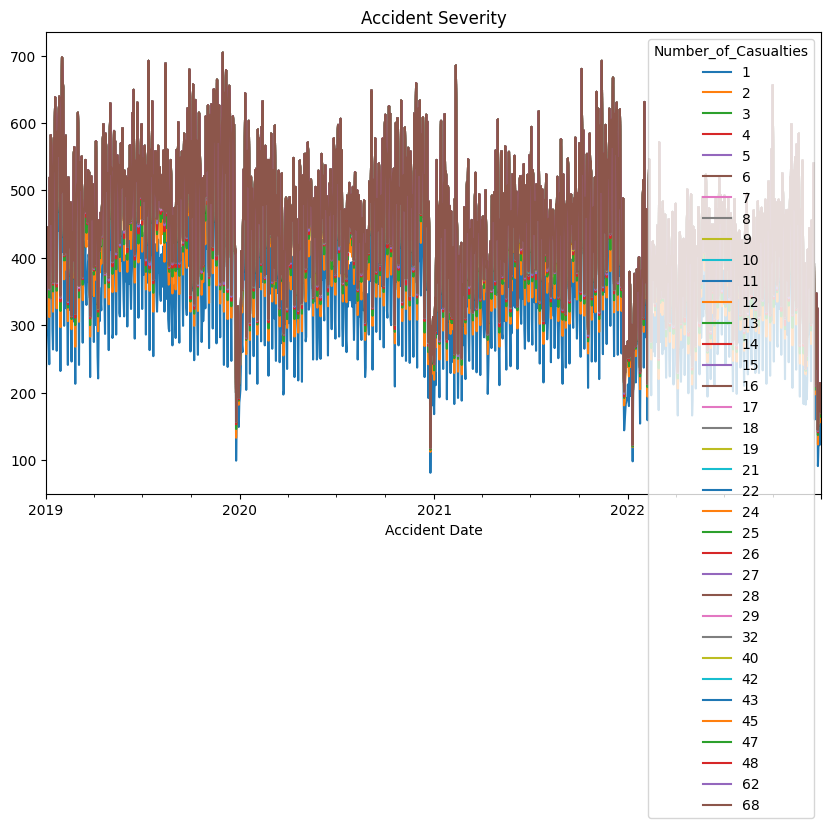

In [40]:
y = accidents.groupby(['Accident Date', 'Number_of_Casualties']).size().unstack()
y.plot(stacked=True, 
       figsize=(10,6),
      title='Accident Severity')
plt.show()

<H2>INSIGHT</H2>
<H3>XXIX. Daily accident counts show consistent patterns with notable COVID-19 impact - there's a clear drop in accidents during early 2020 lockdowns, followed by gradual recovery, with single-casualty accidents (brown) dominating throughout the timeline.</H3>

<h1>24.</h1>

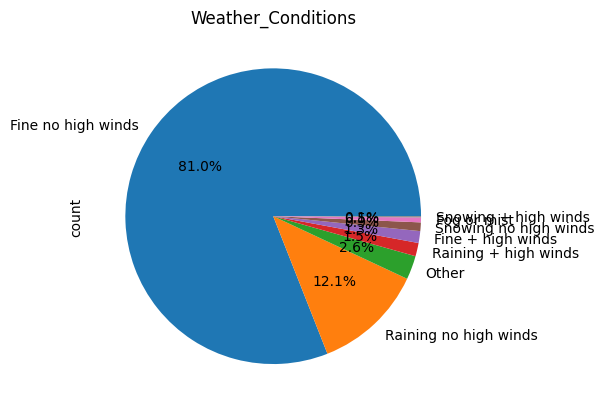

In [41]:
x = accidents['Weather_Conditions'].value_counts()
x.plot(kind='pie',
      title='Weather_Conditions',
      autopct='%.1f%%')
plt.show()

<H2>INSIGHT</H2>
<H3>XXX. Good weather dominates accident statistics - over 80% of accidents occur in fine weather with no high winds, reinforcing that weather conditions are not the main cause of most traffic accidents.</H3>